# 📘 Session 19: Regression Models — Boston Housing
### Duration: ~2.5–3 Hours

---

**Topics Covered:**
1. Classification vs Regression — Predicting Numbers
2. Boston Housing Dataset — Context and Loading
3. Quick EDA and Train / Test Split
4. Preprocessing for Regression
5. Linear Regression — Baseline Model
6. Regression Metrics — MAE, RMSE, and R²
7. Ridge Regression and Random Forest Regressor
8. Residual Analysis and Full Pipeline

---

**Why This Session Matters for Data Science:**
- Many business targets are **numeric**: price, demand, revenue, temperature
- **Regression metrics** (not accuracy) measure how far predictions are from truth
- **Linear models** give interpretable coefficients — useful for explaining drivers
- **Residual plots** reveal when a model systematically misses patterns

> **Prerequisites:** Sessions 16–17 (train/test split, pipelines, scaling). Session 18 metrics focus was classification; today we switch to **continuous targets**.

> **Dataset note:** `sklearn.datasets.load_boston()` was **removed** (ethical concerns about a constructed racial proxy feature). We load the classic teaching copy via **OpenML** and discuss responsible use below.

**Libraries:** `pandas`, `numpy`, `seaborn`, `matplotlib`, **`scikit-learn`**


---
## 1. Classification vs Regression

| Task | Target (y) | Example question | Session 17 metric | Session 19 metric |
|------|------------|------------------|-------------------|-------------------|
| **Classification** | Category | Which species? | Accuracy, F1 | — |
| **Regression** | Number | What is the house price? | — | MAE, RMSE, R² |

### Our project today

| Item | Choice |
|------|--------|
| **Dataset** | Boston Housing (506 suburbs, 13 features) |
| **Target** | `MEDV` — median home value ($1000s) |
| **Goal** | Predict `MEDV` from neighborhood attributes |
| **Models** | Linear Regression, Ridge, Random Forest Regressor |

> **Data Science relevance**: Same sklearn API — `.fit(X, y)`, `.predict(X)` — but `y` is continuous.


---
## 2. Boston Housing Dataset

### Features (13 predictors)

| Feature | Meaning (short) |
|---------|-----------------|
| CRIM | Crime rate |
| ZN | Residential land zoned for large lots |
| INDUS | Non-retail business acres |
| CHAS | Charles River dummy |
| NOX | Nitric oxide concentration |
| RM | Average rooms per dwelling |
| AGE | Proportion of old units |
| DIS | Distance to employment centers |
| RAD | Highway accessibility index |
| TAX | Property tax rate |
| PTRATIO | Pupil-teacher ratio |
| B | *(problematic engineered feature — see note below)* |
| LSTAT | % lower status population |

### Ethical / teaching note

The Boston dataset was widely used for decades but is **deprecated in scikit-learn** because feature **B** encodes a racial segregation proxy. We still use the dataset here to teach **regression mechanics** on a familiar example, but in real projects you should:

- Prefer modern alternatives (e.g. **California Housing** in sklearn)
- Audit features for bias and document limitations
- Never deploy models built on ethically flawed data without review

> ⚠️ **Special Case — loading**: Use `fetch_openml(name='boston', version=1)` (requires internet the first time).


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True, parser="auto")
X = boston.data
y = boston.target.astype(float)

# sklearn OpenML target name is MEDV
if y.name is None:
    y.name = "MEDV"

df = X.copy()
df[y.name] = y

print("Shape:", df.shape)
print("\nFeature dtypes:\n", X.dtypes.value_counts())
print("\nTarget summary:\n", y.describe())
df.head()


Shape: (506, 14)

Feature dtypes:
 float64     11
category     1
category     1
Name: count, dtype: int64

Target summary:
 count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


---
## 3. Quick EDA and Train / Test Split

Before modeling, inspect the **target distribution** and a few relationships.


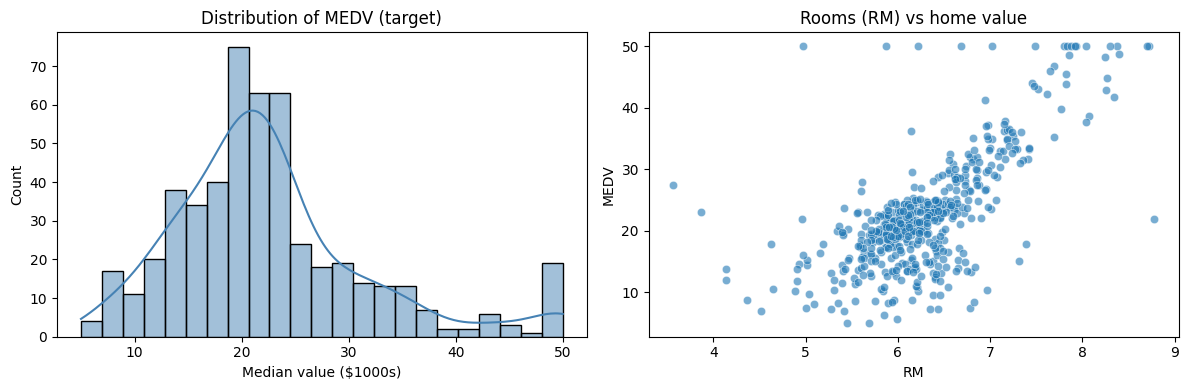

Correlation with MEDV (top 5):
 MEDV       1.000000
LSTAT      0.737663
RM         0.695360
PTRATIO    0.507787
INDUS      0.483725
TAX        0.468536
Name: MEDV, dtype: float64

Train: 404 rows | Test: 102 rows


In [2]:
from sklearn.model_selection import train_test_split

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(y, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of MEDV (target)")
axes[0].set_xlabel("Median value ($1000s)")

sns.scatterplot(data=df, x="RM", y="MEDV", alpha=0.6, ax=axes[1])
axes[1].set_title("Rooms (RM) vs home value")

plt.tight_layout()
plt.show()

print("Correlation with MEDV (top 5):\n",
      df.corr(numeric_only=True)["MEDV"].abs().sort_values(ascending=False).head(6))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)
print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")


---
## 4. Preprocessing for Regression

All Boston features are numeric. **Linear regression** is sensitive to feature scale — use `StandardScaler` (Session 16).

| Step | Tool | Fit on |
|------|------|--------|
| Scale | `StandardScaler` | Train only |

Tree-based regressors (Random Forest) do not require scaling, but we use a pipeline for consistency.


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train RM mean (raw):", X_train["RM"].mean().round(2))
print("Train RM mean (scaled):", X_train_scaled[:, X.columns.get_loc("RM")].mean().round(4))


Train RM mean (raw): 6.32
Train RM mean (scaled): -0.0


---
## 5. Linear Regression — Baseline Model

**Ordinary Least Squares (OLS)** linear regression minimizes squared error between predictions and true `MEDV`.

$$\hat{y} = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$$

| Property | Detail |
|----------|--------|
| **Strengths** | Fast, interpretable coefficients |
| **Weaknesses** | Assumes roughly linear relationships |

```python
from sklearn.linear_model import LinearRegression
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
```


In [4]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lr = lin_reg.predict(X_test_scaled)

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_reg.coef_,
}).sort_values("coefficient", key=abs, ascending=False)

print("Intercept (beta_0):", lin_reg.intercept_.round(3))
print("\nTop coefficients by |size|:\n", coef_df.head(8).to_string(index=False))


Intercept (beta_0): 22.797

Top coefficients by |size|:
 feature  coefficient
  LSTAT    -3.611658
     RM     3.145240
    DIS    -3.081908
    RAD     2.251407
PTRATIO    -2.037752
    NOX    -2.022319
    TAX    -1.767014
      B     1.129568


---
## 6. Regression Metrics — MAE, RMSE, and R²

| Metric | Meaning | Lower is better? |
|--------|---------|------------------|
| **MAE** | Mean absolute error (avg $ error in target units) | Yes |
| **MSE** | Mean squared error | Yes |
| **RMSE** | √MSE (same units as y; penalizes large errors) | Yes |
| **R²** | Fraction of variance explained (1 = perfect, 0 = mean baseline) | Higher is better |

> ⚠️ **Special Case — R² on test** can be negative if the model is worse than predicting the mean.

> **Data Science relevance**: Report **RMSE** or **MAE** in original units ($1000s for MEDV) so stakeholders understand typical error size.


Linear Regression — Test MAE:  3.189 ($1000s)
Linear Regression — Test RMSE: 4.929 ($1000s)
Linear Regression — Test R²:   0.669


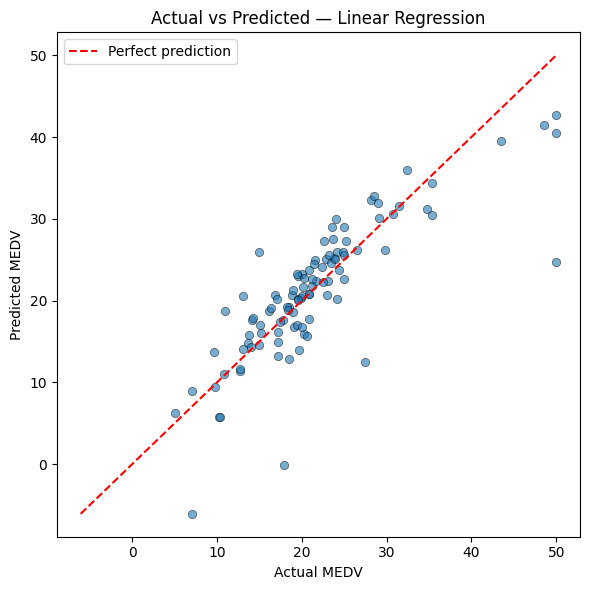

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = root_mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — Test MAE:  {mae:.3f} ($1000s)")
print(f"Linear Regression — Test RMSE: {rmse:.3f} ($1000s)")
print(f"Linear Regression — Test R²:   {r2:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_lr, alpha=0.6, edgecolors="k", linewidth=0.5)
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual MEDV")
ax.set_ylabel("Predicted MEDV")
ax.set_title("Actual vs Predicted — Linear Regression")
ax.legend()
plt.tight_layout()
plt.show()


---
## 7. Ridge Regression and Random Forest Regressor

### Ridge Regression

Adds **L2 penalty** on coefficients to reduce overfitting when features are correlated.

### Random Forest Regressor

Ensemble of trees predicting numeric targets — captures **non-linear** effects (e.g. RM vs MEDV may not be perfectly linear).

Compare all three on the **same test set**.


In [6]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)  # trees: unscaled features OK
y_pred_rf = rf_reg.predict(X_test)

def report(name, y_true, y_pred):
    print(f"{name:22s}  MAE={mean_absolute_error(y_true, y_pred):.3f}  "
          f"RMSE={root_mean_squared_error(y_true, y_pred):.3f}  "
          f"R2={r2_score(y_true, y_pred):.3f}")

print("Test set metrics:\n")
report("Linear Regression", y_test, y_pred_lr)
report("Ridge", y_test, y_pred_ridge)
report("Random Forest", y_test, y_pred_rf)


Test set metrics:

Linear Regression       MAE=3.189  RMSE=4.929  R2=0.669
Ridge                   MAE=3.186  RMSE=4.931  R2=0.668
Random Forest           MAE=2.041  RMSE=2.917  R2=0.884


---
## 8. Residual Analysis and Full Pipeline

**Residual** = actual − predicted. Patterns in residuals suggest the model missed structure (non-linearity, outliers).

| Pattern in residual plot | Suggestion |
|--------------------------|------------|
| Random cloud around 0 | Model OK (for linear assumptions) |
| Curve / funnel shape | Try non-linear model or transforms |
| Outliers | Investigate rows; robust regression later |

### Full pipeline (Linear Regression)

Bundle scaler + model for clean reuse.


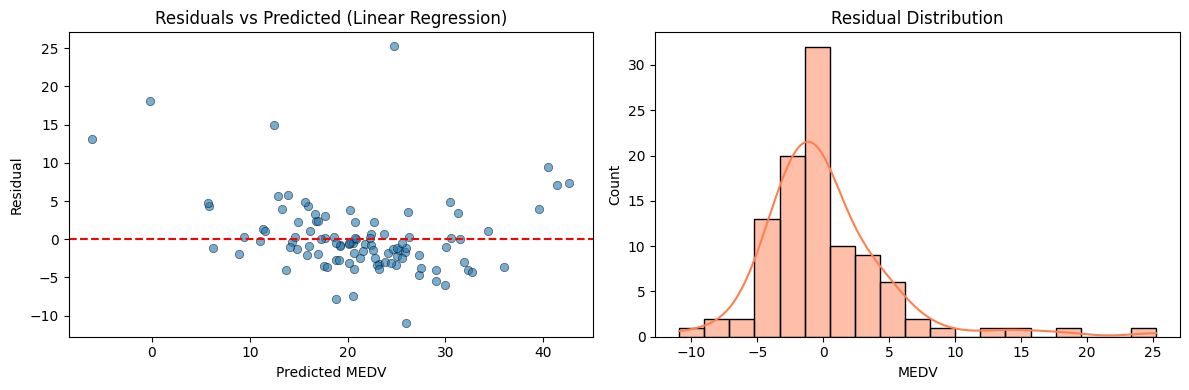

Pipeline test RMSE: 4.929


In [7]:
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_lr, residuals, alpha=0.6, edgecolors="k", linewidth=0.5)
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Predicted MEDV")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted (Linear Regression)")

sns.histplot(residuals, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

# Full pipeline
reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
reg_pipeline.fit(X_train, y_train)
y_pred_pipe = reg_pipeline.predict(X_test)
print(f"Pipeline test RMSE: {root_mean_squared_error(y_test, y_pred_pipe):.3f}")


---
## 🧪 Practice Exercises

1. Which feature has the **strongest negative** correlation with `MEDV`? Does the linear coefficient sign match?
2. Retrain linear regression **without scaling**. Do MAE/RMSE change much? Why does scaling matter more for Ridge?
3. Predict `MEDV` using only `RM` and `LSTAT` as features. Compare test R² to the full 13-feature model.
4. Plot **predicted vs actual** for Random Forest. Which model has smaller RMSE on your split?
5. For Ridge, try `alpha=0.001` and `alpha=100`. How do test RMSE and coefficient sizes change?
6. Find the test row with the **largest absolute residual** (linear model). Print its feature values — any outlier?
7. Read about the Boston dataset ethics issue. In one paragraph, explain why sklearn removed it and what you'd use instead in production.
8. Write a 5-bullet **regression memo**: target, best model, test RMSE in plain English ($1000s), main driver features, recommended next step.

---

## 📝 Session 19 Summary

| Topic | Key takeaway |
|-------|--------------|
| **Regression** | Predict continuous `y`; use MAE/RMSE/R² not accuracy |
| **Boston housing** | Classic example; ethical limitations — use responsibly |
| **Linear Regression** | Interpretable coefficients; needs scaling |
| **Ridge** | Regularized linear model for correlated features |
| **Random Forest Regressor** | Non-linear baseline; feature importances available |
| **Residuals** | Diagnostic for missed patterns |
| **Pipeline** | Scaler + model together |

### Key gotchas
- **R²** alone can hide poor predictions on subsets of data
- **Extrapolation**: linear models may predict nonsense outside training range
- **Boston B feature** — do not treat this dataset as ethically neutral
- Compare models on the **same** test split
- RMSE in **same units as y** — here, $1000s of dollars

### Next Session
**Session 20**: Saving, Loading, and Using ML Models — `joblib` and `pickle` persistence, inference on new data.
